In [1]:
import glob
import uproot
import pandas as pd
import matplotlib.pyplot as plt
try:
#     plt.style.use('belle2')
    # plt.style.use('belle2_serif')
    plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   

In [2]:
BDT_cut="0.86"
Dp_CMS_cosTheta_cut="Dp_CMS_cosTheta>-10"
# 1. Define Paths and Settings (Assuming BDT_cut and Dp_CMS_cosTheta_cut are defined)
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
cm_elements = ["15rd_jae_e7_18_4S_v3", "15rd_jae_e20_b26_v1", "15rd_jae_e20_e26_4S_v2", "15rd_jae_e21_5S_scan_v1", "15rd_jae_mori_off_v1"]
tree_name = "etapip_gg_K"
scale = 1.0

# Define the exact columns you need to save RAM
variables = [
    "Dp_M", "Pip_charge", "rank_Dp_chiProb", "Dp_CMS_cosTheta", "ds_weight",
    "Pip_genMotherID", "etapip_Eta_genMotherID", "etapip_Eta_genMotherPDG",
    "Pip_mcPDG", "etapip_Eta_isSignal"
]

# 2. Collect Files
file_list_non_ccbar = []
file_list_ccbar = []

for element in cm_elements:
    pattern = f"{base_path}/{element}/{tree_name}/min_unc_search/{BDT_cut}/weighted/*BDT.root"
    for f in glob.glob(pattern):
        if "ccbar" not in f:
            file_list_non_ccbar.append(f)

    pattern_ccbar = f"{base_path}/{element}/{tree_name}/min_unc_search/{BDT_cut}/weighted/*ccbar*BDT.root"
    for f in glob.glob(pattern_ccbar):
        file_list_ccbar.append(f)

# 3. Load Data into Pandas DataFrames
# Appending ':tree_name' tells uproot exactly which tree to fetch from the file list
print("Loading non-ccbar data...")
df_non_ccbar = uproot.concatenate([f"{f}:{tree_name}" for f in file_list_non_ccbar], filter_name=variables, library="pd")

print("Loading ccbar data...")
df_ccbar = uproot.concatenate([f"{f}:{tree_name}" for f in file_list_ccbar], filter_name=variables, library="pd")

# Apply weight scaling
df_non_ccbar['w_scaled'] = df_non_ccbar['ds_weight'] * scale
df_ccbar['w_scaled'] = df_ccbar['ds_weight'] * scale

# 4. Define Cuts (Convert C++ syntax to Python pandas.query syntax: || -> or, && -> and)
# NOTE: Ensure Dp_CMS_cosTheta_cut uses 'and'/'or' instead of '&&'/'||' if it is a string
base_Dp_cut = f"Pip_charge == 1 and rank_Dp_chiProb == 1 and {Dp_CMS_cosTheta_cut}"
base_Dm_cut = f"Pip_charge == -1 and rank_Dp_chiProb == 1 and {Dp_CMS_cosTheta_cut}"

# Specific signal veto cuts for ccbar backgrounds
veto_Dp = "(etapip_Eta_isSignal != 1 or Pip_genMotherID != etapip_Eta_genMotherID or etapip_Eta_genMotherPDG != 411 or Pip_mcPDG != 211)"
veto_Dm = "(etapip_Eta_isSignal != 1 or Pip_genMotherID != etapip_Eta_genMotherID or etapip_Eta_genMotherPDG != -411 or Pip_mcPDG != -211)"

# 5. Apply Cuts
print("Applying cuts...")
# Non-ccbar samples
data_Dp_non_ccbar = df_non_ccbar.query(base_Dp_cut)
data_Dm_non_ccbar = df_non_ccbar.query(base_Dm_cut)

# ccbar samples
data_Dp_ccbar = df_ccbar.query(f"{base_Dp_cut} and {veto_Dp}")
data_Dm_ccbar = df_ccbar.query(f"{base_Dm_cut} and {veto_Dm}")

# Append matching categories
data_Dp = pd.concat([data_Dp_non_ccbar, data_Dp_ccbar], ignore_index=True)
data_Dm = pd.concat([data_Dm_non_ccbar, data_Dm_ccbar], ignore_index=True)

print(f"Total Dp entries: {len(data_Dp)}")
print(f"Total Dm entries: {len(data_Dm)}")

Loading non-ccbar data...
Loading ccbar data...
Applying cuts...
Total Dp entries: 48441
Total Dm entries: 48670


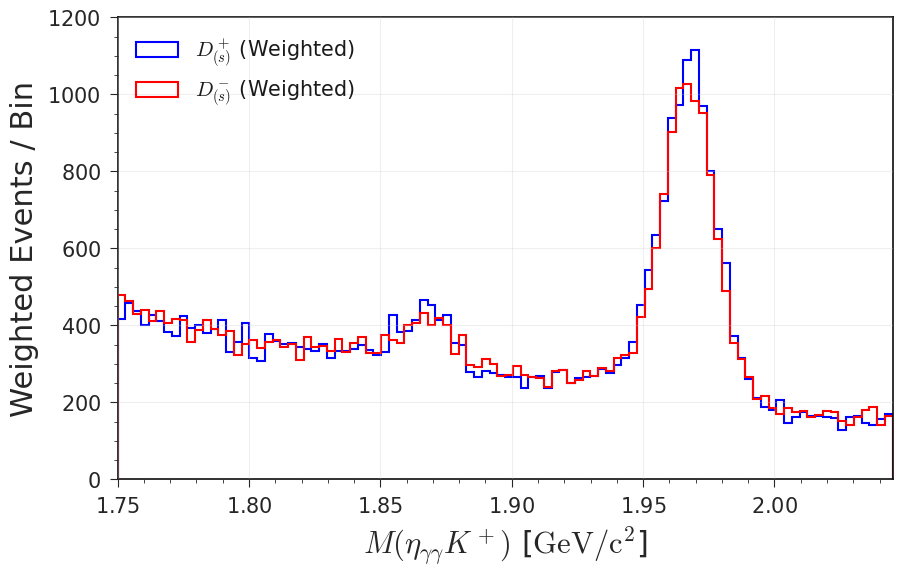

In [25]:
# 6. Draw the Histograms in the specified region
fit_range = (1.75, 2.045)

plt.figure(figsize=(10, 6))

# Plot D+
plt.hist(data_Dp['Dp_M'], bins=100, range=fit_range, weights=data_Dp['w_scaled'],
         histtype='step', linewidth=1.5, label='$D^+_{(s)}$ (Weighted)', color='blue')

# Plot D-
plt.hist(data_Dm['Dp_M'], bins=100, range=fit_range, weights=data_Dm['w_scaled'],
         histtype='step', linewidth=1.5, label='$D^-_{(s)}$ (Weighted)', color='red')

# plt.title(r'Invariant Mass of $\eta_{\gamma\gamma}K^{\pm}$')
xlabel = r"$M(\eta_{\gamma\gamma}K^+)$ [$\mathrm{GeV/c^2}$]"
plt.xlabel(xlabel)
plt.ylabel('Weighted Events / Bin')
plt.xlim(fit_range)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()
# plt.savefig('histo_Dp_Dm_etapip_gg_K.png')

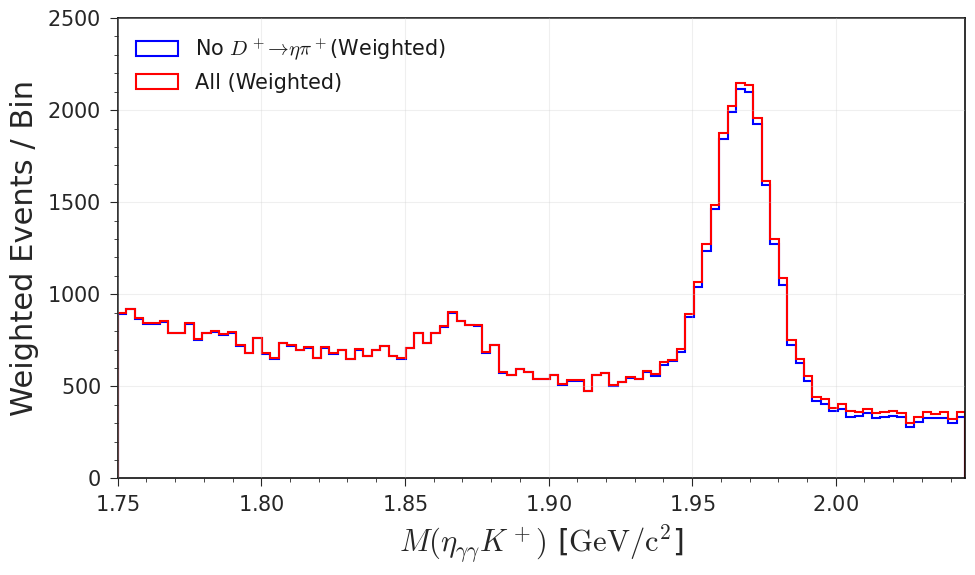

In [26]:
plt.figure(figsize=(10, 6))
# fit_range = (1.75, 1.93)

data_Dall = pd.concat([data_Dp, data_Dm], ignore_index=True)
data_Dp_ccbar_org = df_ccbar.query(f"{base_Dp_cut}")
data_Dm_ccbar_org = df_ccbar.query(f"{base_Dm_cut}")
data_Dall_org = pd.concat([data_Dp_non_ccbar, data_Dm_non_ccbar, data_Dp_ccbar_org, data_Dm_ccbar_org], ignore_index=True)

# Plot Dall
plt.hist(data_Dall['Dp_M'], bins=100, range=fit_range, weights=data_Dall['w_scaled'],
         histtype='step', linewidth=1.5, label=r'No $D^+ \to \eta \pi^+$(Weighted)', color='blue')
plt.hist(data_Dall_org['Dp_M'], bins=100, range=fit_range, weights=data_Dall_org['w_scaled'],
         histtype='step', linewidth=1.5, label='All (Weighted)', color='red')

xlabel = r"$M(\eta_{\gamma\gamma}K^+)$ [$\mathrm{GeV/c^2}$]"
plt.xlabel(xlabel)
plt.ylabel('Weighted Events / Bin')
plt.xlim(fit_range)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
# plt.xlim(1.82, 1.93)
plt.tight_layout()
plt.savefig('histo_Dall_etapip_gg_K.png')
plt.show()


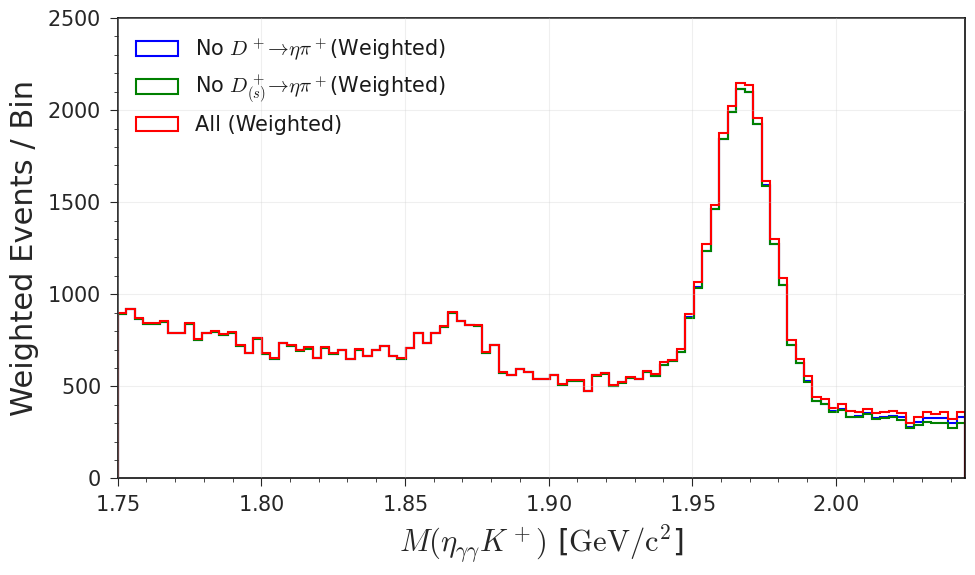

In [27]:
plt.figure(figsize=(10, 6))

data_Dall = pd.concat([data_Dp, data_Dm], ignore_index=True)

data_Dp_ccbar_org = df_ccbar.query(f"{base_Dp_cut}")
data_Dm_ccbar_org = df_ccbar.query(f"{base_Dm_cut}")
data_Dall_org = pd.concat([data_Dp_non_ccbar, data_Dm_non_ccbar, data_Dp_ccbar_org, data_Dm_ccbar_org], ignore_index=True)

veto_Dsp = "(etapip_Eta_isSignal != 1 or Pip_genMotherID != etapip_Eta_genMotherID or etapip_Eta_genMotherPDG != 431 or Pip_mcPDG != 211)"
veto_Dsm = "(etapip_Eta_isSignal != 1 or Pip_genMotherID != etapip_Eta_genMotherID or etapip_Eta_genMotherPDG != -431 or Pip_mcPDG != -211)"
data_Dp_ccbar_no_DsEtaHp = data_Dp_ccbar.query(f"{base_Dp_cut} and {veto_Dsp}")
data_Dm_ccbar_no_DsEtaHp = data_Dm_ccbar.query(f"{base_Dm_cut} and {veto_Dsm}")
data_Dall_no_D_Ds_EtaHp = pd.concat([data_Dp_non_ccbar, data_Dm_non_ccbar, data_Dp_ccbar_no_DsEtaHp, data_Dm_ccbar_no_DsEtaHp], ignore_index=True)


# Plot Dall
plt.hist(data_Dall['Dp_M'], bins=100, range=fit_range, weights=data_Dall['w_scaled'],
         histtype='step', linewidth=1.5, label=r'No $D^+ \to \eta \pi^+$(Weighted)', color='blue')
plt.hist(data_Dall_no_D_Ds_EtaHp['Dp_M'], bins=100, range=fit_range, weights=data_Dall_no_D_Ds_EtaHp['w_scaled'],
         histtype='step', linewidth=1.5, label=r'No $D^+_{(s)} \to \eta \pi^+$(Weighted)', color='green')
plt.hist(data_Dall_org['Dp_M'], bins=100, range=fit_range, weights=data_Dall_org['w_scaled'],
         histtype='step', linewidth=1.5, label='All (Weighted)', color='red')

xlabel = r"$M(\eta_{\gamma\gamma}K^+)$ [$\mathrm{GeV/c^2}$]"
plt.xlabel(xlabel)
plt.ylabel('Weighted Events / Bin')
plt.xlim(fit_range)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('histo_Dall_etapip_gg_K_alsoexcept_Ds.png')
plt.show()
